In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


In [ ]:
#auction hourly day-ahead price
price = pd.read_csv('data/de_lu_day_ahead_price_hourly.csv', parse_dates=['ts_utc'])
# electricity consumption (load): forecast and realized
load  = pd.read_csv('data/de_lu_load_hourly.csv', parse_dates=['ts_utc'])
# generated power by type (nuclear, coal, gas, hydro,...)
gen   = pd.read_csv('data/de_lu_generation_by_type_hourly.csv', parse_dates=['ts_utc'])
# day ahead froecast of solar and wind in mw
ws    = pd.read_csv('data/de_lu_wind_solar_da_forecast_hourly.csv', parse_dates=['ts_utc'])
# installed capacity for different production types, one value for 2025 and 2026
cap   = pd.read_csv('data/de_lu_installed_capacity_yearly.csv')
# daily prices from different hubs 
fuel  = pd.read_csv('data/fuel_carbon_prices_daily.csv', parse_dates=['date'])

In [14]:
fuel

,date,gas_the_day_ahead_eur_mwh,gas_ttf_day_ahead_eur_mwh,eua_dec_front_settle_eur_t,eua_dec_front_contract
0,2025-01-02,50.751,49.993,75.19,Dec-2025
1,2025-01-03,50.167,49.455,75.94,Dec-2025
2,2025-01-06,47.921,46.961,74.36,Dec-2025
3,2025-01-07,48.526,47.523,74.04,Dec-2025
4,2025-01-08,46.464,45.621,72.17,Dec-2025
...,...,...,...,...,...
400,2026-08-03,57.927,57.644,80.87,Dec-2026
401,2026-08-04,55.876,55.404,81.35,Dec-2026
402,2026-08-05,52.945,52.442,81.11,Dec-2026
403,2026-08-06,56.465,56.124,81.91,Dec-2026


/tmp/ipykernel_1005603/2649750605.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


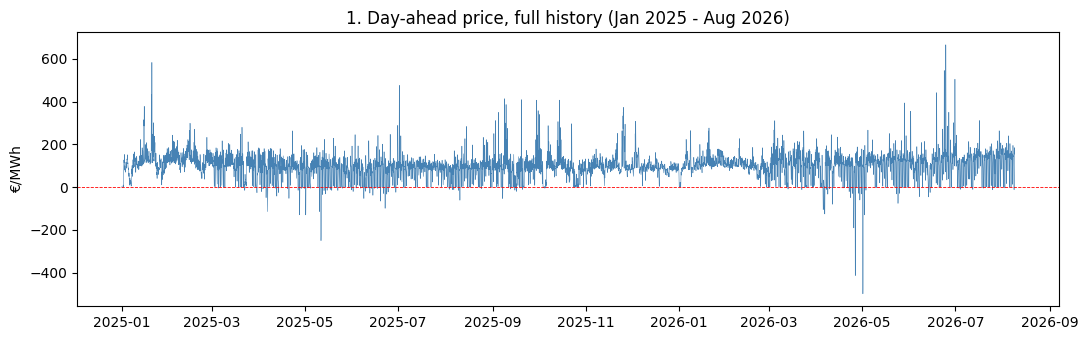

In [15]:
fig, ax = plt.subplots(figsize=(11,3.5))
ax.plot(price.ts_utc, price.price_eur_mwh, lw=0.4, color='steelblue')
ax.axhline(0, color='red', lw=0.6, ls='--')
ax.set_title('1. Day-ahead price, full history (Jan 2025 - Aug 2026)')
ax.set_ylabel('€/MWh')
fig.tight_layout()
fig.show()

## Price history jan 2025 - Aug 2026

* It mostly sits around 50 to 150 eur/MWh but it has frequent spikes in both directions (going up in price or down)
* The spikes don't appear to be random noise scattered evenly through time: they cluster (spike near january 2025 and then another in may of 2026). This shows that the price is driven by specific conditions (weather, demand, fuel costs).
* This behaviour (normal + extreme tails) is why we need to present p10 and p90 bands rather than a single number: a plain average forecast would smear over these spikes and be wrong most of the time.

/tmp/ipykernel_1005603/3159307507.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


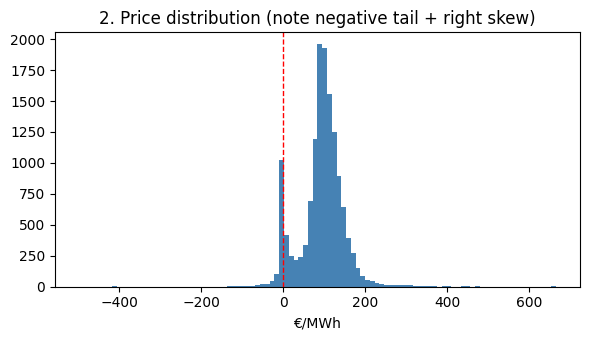

In [19]:
fig, ax = plt.subplots(figsize=(6,3.5))
ax.hist(price.price_eur_mwh, bins=100, color='steelblue')
ax.axvline(0, color='red', lw=1, ls='--')
ax.set_title('2. Price distribution (note negative tail + right skew)')
ax.set_xlabel('€/MWh')
fig.tight_layout()
fig.show()

## Price distribution histogram

* Near symmetric distribution around 90-100 eur/MWh, but with 2 features:
    * A left tail stretching to -400 eur: this happens when renewable output is so high relative to demand that generators pay to keep running rather than shut down.
    * A long right tail: scarcity spikes when demand is high and renewables are scarce, so the marked has to call on expensive backup plans

/tmp/ipykernel_1005603/702025648.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


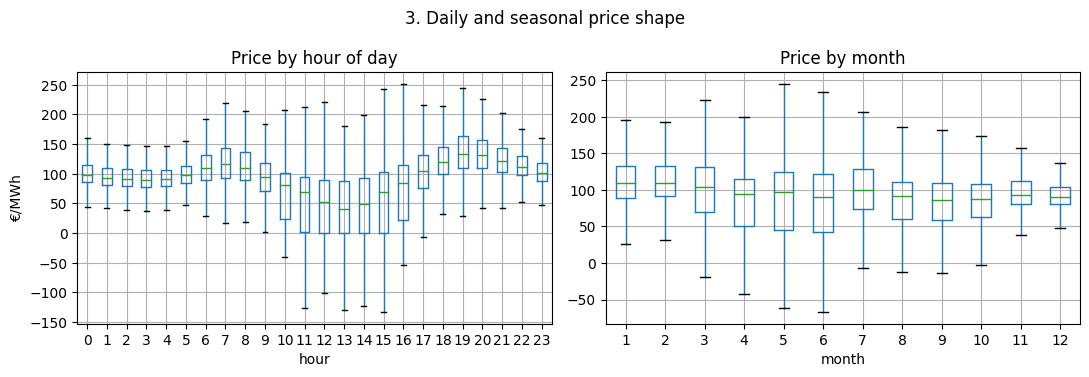

In [20]:
local = pd.to_datetime(price.ts_local)
price = price.copy()
price['hour'] = local.dt.hour
price['month'] = local.dt.month
fig, axes = plt.subplots(1,2, figsize=(11,3.8))
price.boxplot(column='price_eur_mwh', by='hour', ax=axes[0], showfliers=False)
axes[0].set_title('Price by hour of day'); axes[0].set_xlabel('hour'); axes[0].set_ylabel('€/MWh')
price.boxplot(column='price_eur_mwh', by='month', ax=axes[1], showfliers=False)
axes[1].set_title('Price by month'); axes[1].set_xlabel('month')
fig.suptitle('3. Daily and seasonal price shape')
fig.tight_layout()
fig.show()

## Prices by hour and season
* By hour: prices peak in the morning (7-9h) and in the evening (18-20h), and sag around 11h-15h when solar power floods the grid: the median even dips towards zero and the lower whisker goes deeply negative in that window.
* By month: winter months have the highest, tightest packed prices (more heating demand and less solar). Spring/summer months have lower medias but much wider boxes stretching into negative territory: that's the solar oversupply effect again.

/tmp/ipykernel_1005603/966252169.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zoom['local'] = pd.to_datetime(zoom.ts_local)
/tmp/ipykernel_1005603/966252169.py:10: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


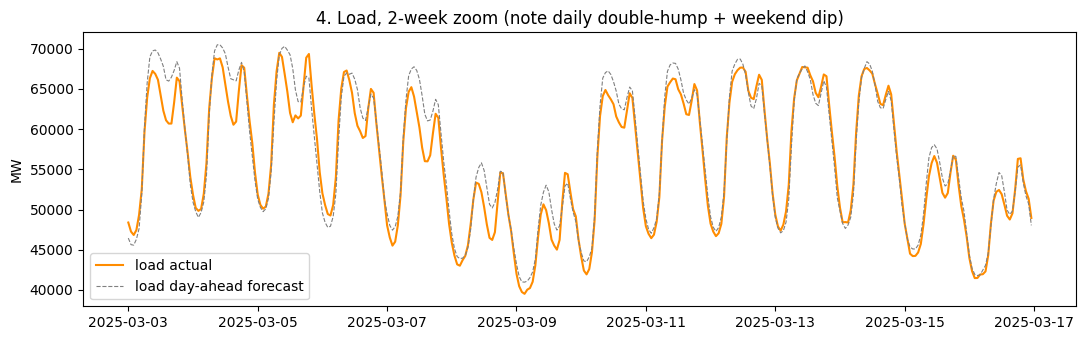

In [26]:
local = pd.to_datetime(load.ts_local)
zoom = load[(local >= '2025-03-03') & (local < '2025-03-17')]
zoom['local'] = pd.to_datetime(zoom.ts_local)
fig, ax = plt.subplots(figsize=(11,3.5))
ax.plot(zoom.local, zoom.load_actual_mw, label='load actual', color='darkorange')
ax.plot(zoom.local, zoom.load_da_forecast_mw, label='load day-ahead forecast', color='gray', ls='--', lw=0.8)
ax.set_title('4. Load, 2-week zoom (note daily double-hump + weekend dip)')
ax.set_ylabel('MW'); ax.legend()
fig.tight_layout()
fig.show()

## Germany+Lux overall electricity demand of 2 weeks
* Daily double hup: a morning peak and midday dip, and an evening peak: the classic industrial/commercial demand pattern (independent of solar, just when people and factories use electricity)
* Weekend vs weekday: the 2 low troughs (Mar 8-9, Mar 15-26) are weekends
* Actual vs forecast: the day ahead load forecast is quite good, which matters because this forecast, not the actual, is what the market sees before the price is set. The model should be trained on the forecast and not the actual.

/tmp/ipykernel_1005603/801268156.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  week['local'] = pd.to_datetime(week.ts_local)
/tmp/ipykernel_1005603/801268156.py:30: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


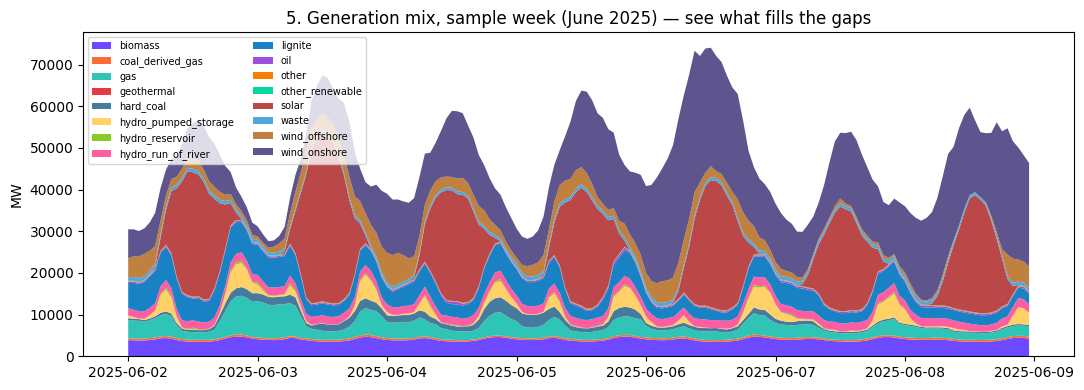

In [28]:
local = pd.to_datetime(gen.ts_local)
week = gen[(local >= '2025-06-02') & (local < '2025-06-09')]
week['local'] = pd.to_datetime(week.ts_local)
gen_cols = [c for c in gen.columns
                if c.startswith('gen_') and c not in ('gen_total_mw', 'gen_hydro_pumped_storage_consumption_mw')]

colors = [
    "#6d4aff",  # purple
    "#ff6b35",  # orange
    "#2ec4b6",  # teal
    "#e63946",  # red
    "#457b9d",  # steel blue
    "#ffd166",  # yellow
    "#8ac926",  # green
    "#ff5da2",  # pink
    "#1982c4",  # bright blue
    "#9d4edd",  # violet
    "#f77f00",  # amber
    "#06d6a0",  # mint
    "#bc4749",  # brick
    "#4ea8de",  # sky blue
    "#bf8040",  # brown/tan
    "#5e548e",  # muted plum
]
fig, ax = plt.subplots(figsize=(11,4))
ax.stackplot(week.local, [week[c] for c in gen_cols], labels=[c.replace('gen_','').replace('_mw','') for c in gen_cols], colors=colors)
ax.set_title('5. Generation mix, sample week (June 2025) — see what fills the gaps')
ax.set_ylabel('MW'); ax.legend(loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
fig.show()

/tmp/ipykernel_1005603/1633656039.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  week['local'] = pd.to_datetime(week.ts_local)
/tmp/ipykernel_1005603/1633656039.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1005603/1633656039.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  week['local'] = pd.to_datetime(week.ts_local)
/tmp/ipykernel_1005603/1633656039.py:16: UserWarning:

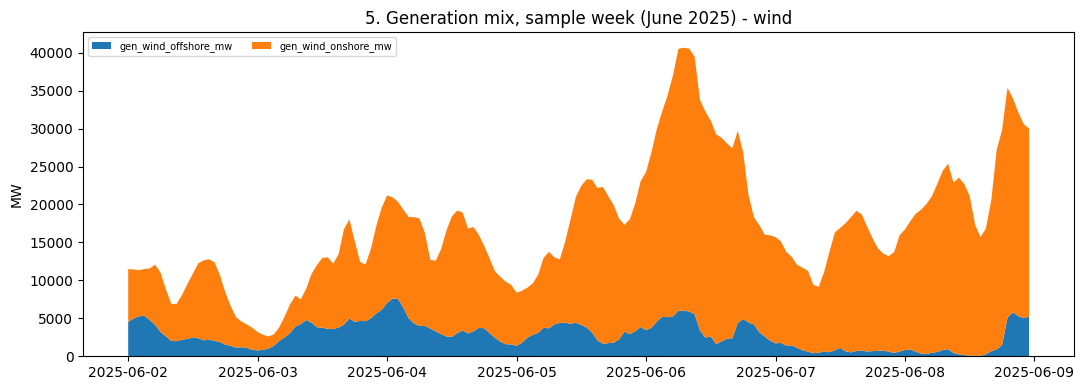

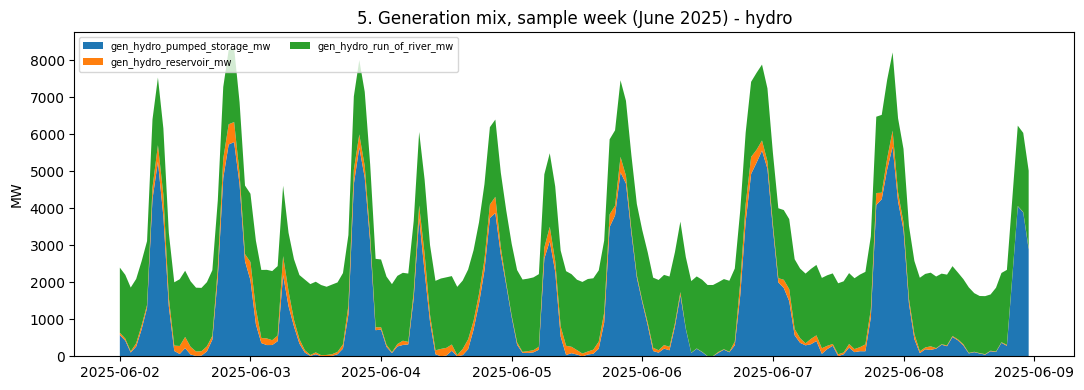

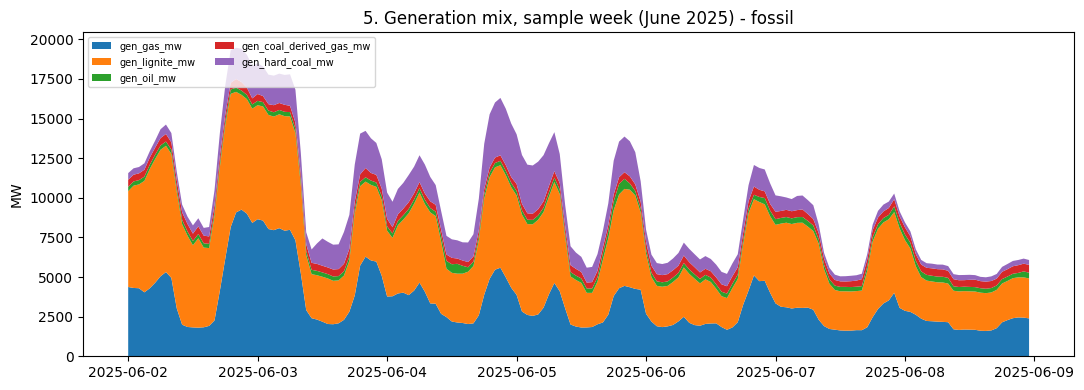

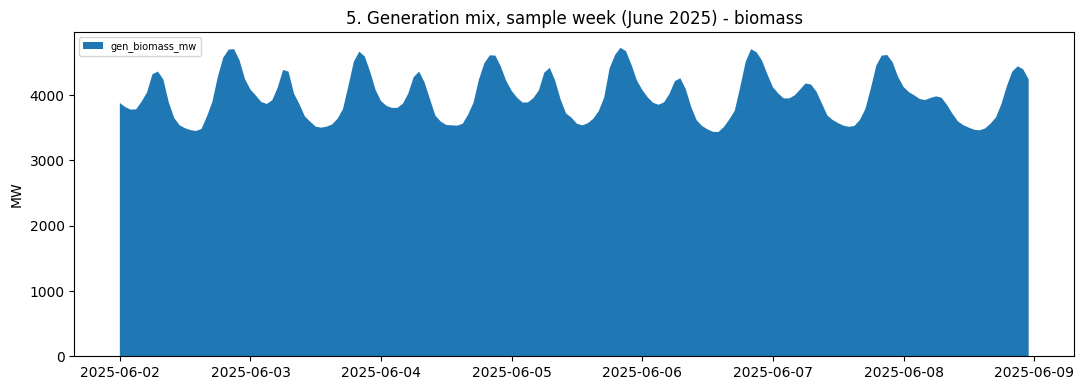

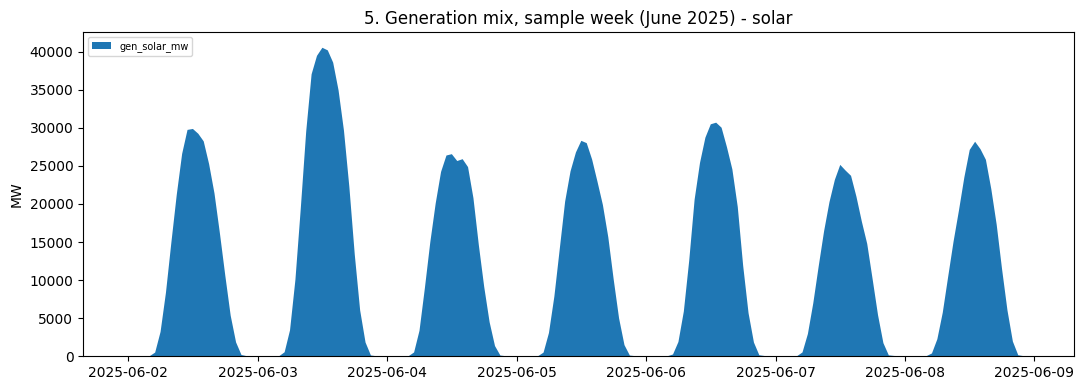

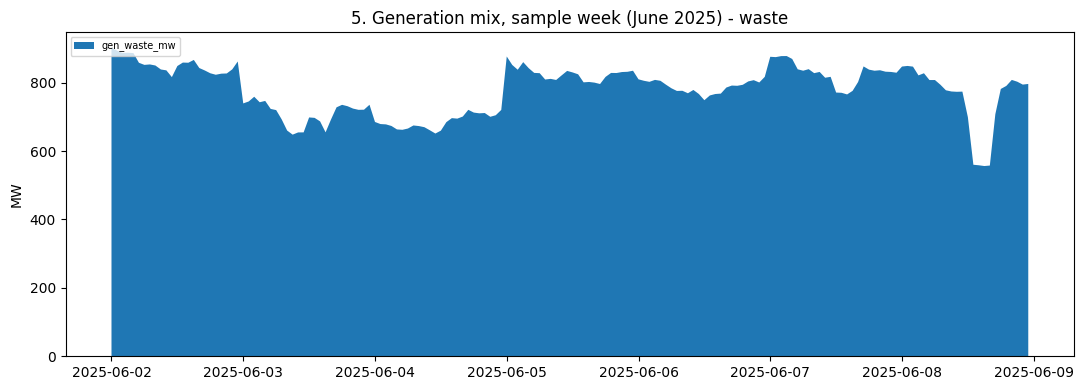

In [92]:
def plot_stacked(col, gen, title):
    stacked_gen = pd.DataFrame()
    stacked_gen["ts_local"] = gen["ts_local"]
    for c in col:
        stacked_gen[c] = gen[c]
    local = pd.to_datetime(stacked_gen.ts_local)
    week = stacked_gen[(local >= '2025-06-02') & (local < '2025-06-09')]
    week['local'] = pd.to_datetime(week.ts_local)
    stacked_gen_cols = [c for c in stacked_gen.columns
                if c not in ('ts_local')]
    fig, ax = plt.subplots(figsize=(11,4))
    ax.stackplot(week.local, [week[c] for c in stacked_gen_cols], labels=[c for c in stacked_gen_cols])
    ax.set_title('5. Generation mix, sample week (June 2025) - '+title)
    ax.set_ylabel('MW'); ax.legend(loc='upper left', fontsize=7, ncol=2)
    fig.tight_layout()
    fig.show()

plot_stacked(col=["gen_wind_offshore_mw","gen_wind_onshore_mw"], gen=gen, title="wind")
plot_stacked(col=["gen_hydro_pumped_storage_mw","gen_hydro_reservoir_mw","gen_hydro_run_of_river_mw"], gen=gen, title="hydro")
plot_stacked(col=["gen_gas_mw","gen_lignite_mw","gen_oil_mw","gen_coal_derived_gas_mw","gen_hard_coal_mw"], gen=gen, title="fossil")
plot_stacked(col=["gen_biomass_mw"], gen=gen, title="biomass")
plot_stacked(col=["gen_solar_mw"], gen=gen, title="solar")
plot_stacked(col=["gen_waste_mw"], gen=gen, title="waste")

/tmp/ipykernel_1005603/1741556165.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  week['local'] = pd.to_datetime(week.ts_local)
/tmp/ipykernel_1005603/1741556165.py:25: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


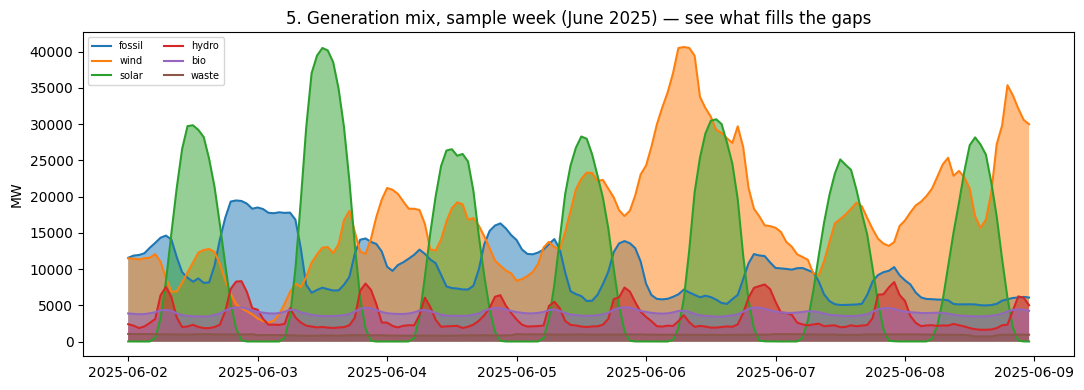

In [94]:
stacked_gen = pd.DataFrame()
stacked_gen["ts_local"] = gen["ts_local"]
stacked_gen["fossil"] = gen["gen_gas_mw"]+gen["gen_lignite_mw"]+gen["gen_oil_mw"]+gen["gen_coal_derived_gas_mw"]+gen["gen_hard_coal_mw"]
stacked_gen["wind"] = gen["gen_wind_offshore_mw"]+gen["gen_wind_onshore_mw"]
stacked_gen["solar"] = gen["gen_solar_mw"]
stacked_gen["hydro"] = gen["gen_hydro_pumped_storage_mw"]+gen["gen_hydro_reservoir_mw"]+gen["gen_hydro_run_of_river_mw"]
stacked_gen["bio"] = gen["gen_biomass_mw"]
stacked_gen["waste"] =gen["gen_waste_mw"]+gen["gen_other_mw"]

local = pd.to_datetime(stacked_gen.ts_local)
week = stacked_gen[(local >= '2025-06-02') & (local < '2025-06-09')]
week['local'] = pd.to_datetime(week.ts_local)
stacked_gen_cols = [c for c in stacked_gen.columns
                if c not in ('ts_local')]
fig, ax = plt.subplots(figsize=(11,4))
#ax.stackplot(week.local, [week[c]/week[c].max() for c in stacked_gen_cols], labels=[c for c in stacked_gen_cols])
for c in stacked_gen_cols:
    # ax.plot(week.local, week[c]/week[c].max(), label=c,)
    # ax.fill_between(week.local, week[c]/week[c].max(), alpha=0.3)
    ax.plot(week.local, week[c], label=c,)
    ax.fill_between(week.local, week[c], alpha=0.5)
ax.set_title('5. Generation mix, sample week (June 2025) — see what fills the gaps')
ax.set_ylabel('MW'); ax.legend(loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
fig.show()

## Generation mix: week in june
* Stable baseload band at the bottom (waste and biomass): seems like it has consistent use but very little compared to the rest
* solar: expected peaks at middle of the day
* hydro and fossil: it ramps up in the evening as solar fades
* wind: very chaotic

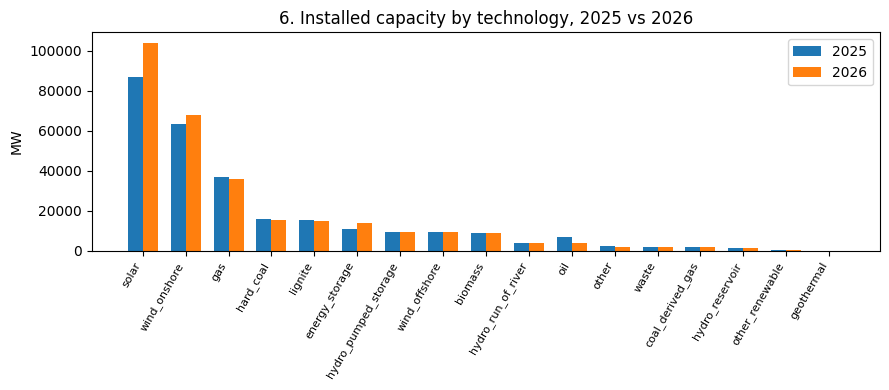

In [95]:
cap = cap.sort_values('installed_mw_2026', ascending=False)
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(cap)); w=0.35
ax.bar(x-w/2, cap.installed_mw_2025, w, label='2025')
ax.bar(x+w/2, cap.installed_mw_2026, w, label='2026')
ax.set_xticks(x); ax.set_xticklabels(cap.technology, rotation=60, ha='right', fontsize=8)
ax.set_title('6. Installed capacity by technology, 2025 vs 2026')
ax.set_ylabel('MW'); ax.legend()
fig.tight_layout()

## Capacity: structural story of German+Lux grid
* Solar grew from 87 GW to 104 GW: installed in a single year (+20%), by far the largest techonology already and still growing the fastest
* Battery/energy storage: grew from 11 GW to 14 GW (+27%): storage is becoming a real player, which matters because storage is exactly what would smooth out the negative price/spike dynamic from plot 1
* Fossil shrinked from 2025 to 2026

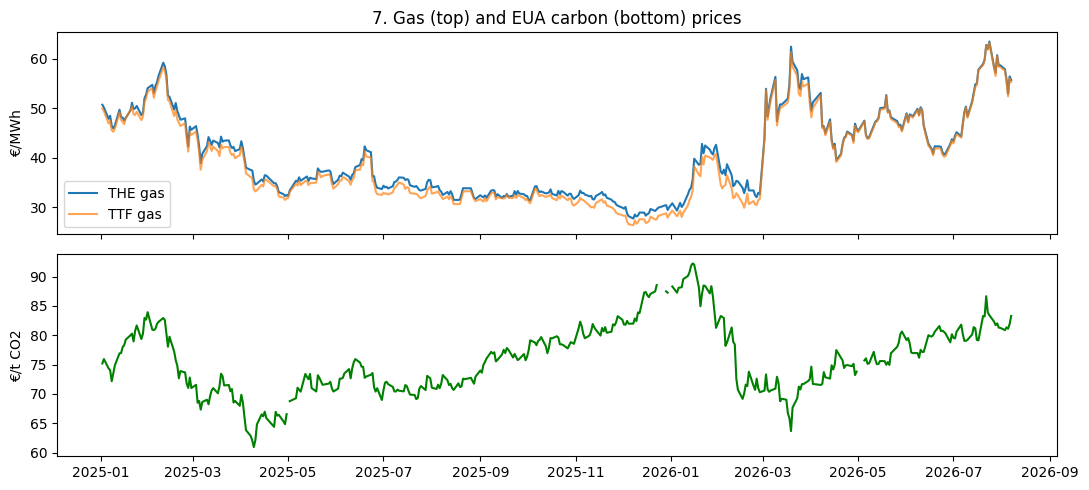

In [96]:
fig, axes = plt.subplots(2,1, figsize=(11,5), sharex=True)
axes[0].plot(fuel.date, fuel.gas_the_day_ahead_eur_mwh, label='THE gas')
axes[0].plot(fuel.date, fuel.gas_ttf_day_ahead_eur_mwh, label='TTF gas', alpha=0.7)
axes[0].set_ylabel('€/MWh'); axes[0].legend(); axes[0].set_title('7. Gas (top) and EUA carbon (bottom) prices')
axes[1].plot(fuel.date, fuel.eua_dec_front_settle_eur_t, color='green')
axes[1].set_ylabel('€/t CO2')
fig.tight_layout()

# Fuel cost input
* Gas fell from 50 eur/MWh (Jan 2025) down to 28 eur/MWh (Autumn 2025), then rebounded sharply, spiking at 60+ eur by mid 2026 (seasonal? Trump?)
* THE and TTF gas tracks are almost identical: the THE (German Hub) trades at a small, consistent premium over TTF (european benchmark). Basically can use only one of them as a feature
* EUA carbon price: trends generally upward with a lot of choppiness, no obvious seasonal pattern (unlike gas)

/tmp/ipykernel_1005603/610067511.py:21: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


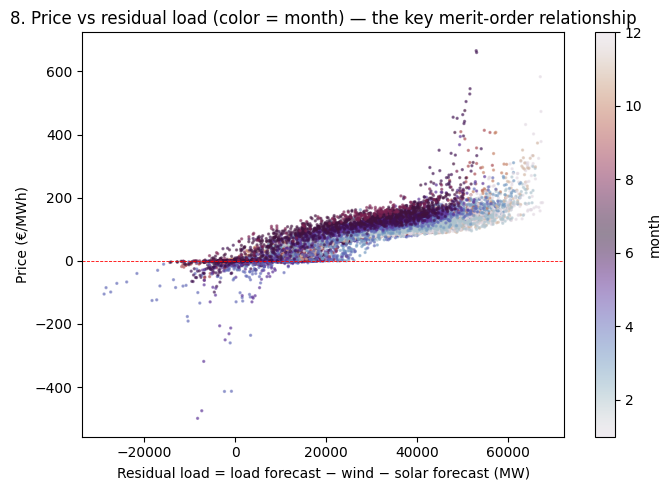

In [104]:
price = price[['ts_utc', 'ts_local', 'price_eur_mwh']]
load = load[['ts_utc', 'load_da_forecast_mw']]
ws = ws[['ts_utc', 'da_forecast_solar_mw',
                            'da_forecast_wind_offshore_mw', 'da_forecast_wind_onshore_mw']]

df = price.merge(load, on='ts_utc', how='inner').merge(ws, on='ts_utc', how='inner')

df['res_load'] = (df.load_da_forecast_mw
                    - df.da_forecast_solar_mw
                    - df.da_forecast_wind_offshore_mw
                    - df.da_forecast_wind_onshore_mw)
df['month'] = pd.to_datetime(df.ts_local).dt.month
fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(df.res_load, df.price_eur_mwh, s=2, alpha=0.5, c=df.month, cmap='twilight')
ax.axhline(0, color='red', lw=0.6, ls='--')
ax.set_xlabel('Residual load = load forecast − wind − solar forecast (MW)')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('8. Price vs residual load (color = month) — the key merit-order relationship')
cbar = fig.colorbar(sc, ax=ax, label='month')
fig.tight_layout()
fig.show()

## Price vs residual load
* Most important plot
* Residual load: total demand minus what wind and solar are already covering. "How much electricity still needs to come from a controllable power plant (gas, coal, hydro, biomass) after nature has done its part"
* Power plants are dispatched cheapest first: wind/solar/nuclear first, then hydro, then gas, then coal, in order of their fuel+carbon cost
* The market price in a given hour equals the cost of the most expensive plant still needed to meet demand: the marginal plant
* When residual load is negative (renewables > demand), no fossil plant is needed at all, and price falls to zero or negative (left side of plot)
* When residual load is low-to-moderate (renewables cover most of demand), only cheap plants are on the margin: price is flat and low (the flat band around residual load between 0-20 GW)
* When residual load is high (renewables scarce, demand high), increasingly expensive plants get called in, and the curve bends sharply upward: that's the scarcity pricing region on the right


/tmp/ipykernel_1005603/1545334559.py:23: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


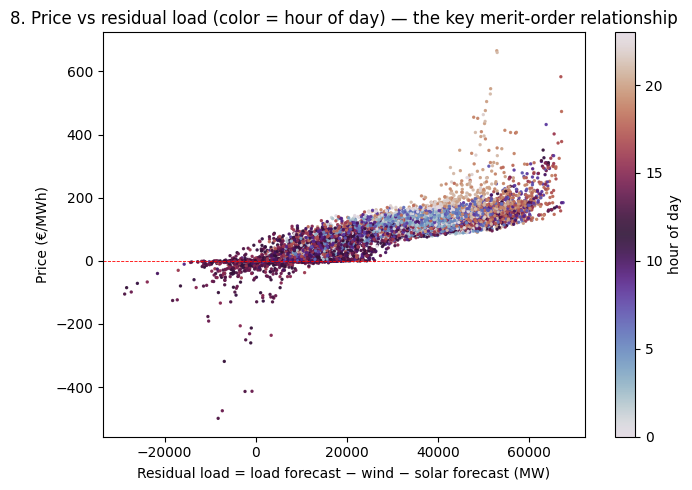

In [107]:
price = price[['ts_utc', 'ts_local', 'price_eur_mwh']]
load = load[['ts_utc', 'load_da_forecast_mw']]
ws = ws[['ts_utc', 'da_forecast_solar_mw',
                            'da_forecast_wind_offshore_mw', 'da_forecast_wind_onshore_mw']]

df = price.merge(load, on='ts_utc', how='inner').merge(ws, on='ts_utc', how='inner')

df['res_load'] = (df.load_da_forecast_mw
                    - df.da_forecast_solar_mw
                    - df.da_forecast_wind_offshore_mw
                    - df.da_forecast_wind_onshore_mw)
# day of week: 0=Monday ... 6=Sunday
df['hour'] = pd.to_datetime(df.ts_local).dt.hour

fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(df.res_load, df.price_eur_mwh, s=2, alpha=0.9, c=df.hour, cmap='twilight', vmin=0, vmax=23)
ax.axhline(0, color='red', lw=0.6, ls='--')
ax.set_xlabel('Residual load = load forecast − wind − solar forecast (MW)')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('8. Price vs residual load (color = hour of day) — the key merit-order relationship')
cbar = fig.colorbar(sc, ax=ax, label='hour of day')
fig.tight_layout()
fig.show()

In [102]:
week

,ts_utc,ts_local,price_eur_mwh,load_da_forecast_mw,da_forecast_solar_mw,da_forecast_wind_offshore_mw,da_forecast_wind_onshore_mw,res_load,local
3647,2025-06-01 22:00:00+00:00,2025-06-02 00:00,81.76,40454.368,0.000,4741.340,6543.913,29169.115,2025-06-02 00:00:00
3648,2025-06-01 23:00:00+00:00,2025-06-02 01:00,75.31,39521.790,0.000,5139.105,6101.465,28281.220,2025-06-02 01:00:00
3649,2025-06-02 00:00:00+00:00,2025-06-02 02:00,75.00,39198.655,0.000,5175.045,6306.188,27717.422,2025-06-02 02:00:00
3650,2025-06-02 01:00:00+00:00,2025-06-02 03:00,77.75,39643.110,0.000,4899.738,6783.468,27959.904,2025-06-02 03:00:00
3651,2025-06-02 02:00:00+00:00,2025-06-02 04:00,83.05,40769.115,5.322,4422.297,7319.910,29021.586,2025-06-02 04:00:00
...,...,...,...,...,...,...,...,...,...
3810,2025-06-08 17:00:00+00:00,2025-06-08 19:00,39.65,45856.030,6402.688,3346.125,26496.717,9610.500,2025-06-08 19:00:00
3811,2025-06-08 18:00:00+00:00,2025-06-08 20:00,60.88,45474.805,2052.443,3677.963,24157.552,15586.847,2025-06-08 20:00:00
3812,2025-06-08 19:00:00+00:00,2025-06-08 21:00,69.55,44708.580,170.795,3754.323,22806.307,17977.155,2025-06-08 21:00:00
3813,2025-06-08 20:00:00+00:00,2025-06-08 22:00,65.07,43539.615,2.025,3708.913,21805.482,18023.195,2025-06-08 22:00:00
